Rendering Symbiotic-Contract GIF...
Displaying symbiotic-contract...



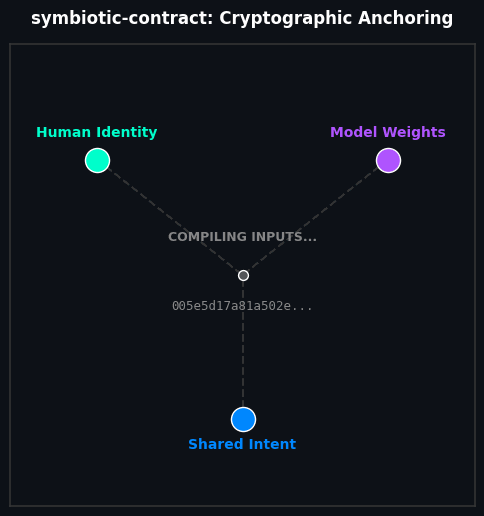

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
import random
from IPython.display import display, HTML
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
FRAMES = 90
FPS = 30
BG_COLOR = "#0d1117"  # GitHub Dark
COLOR_HUMAN = "#00ffcc"   # Cyan
COLOR_MODEL = "#b055ff"   # Purple
COLOR_INTENT = "#0088ff"  # Blue
COLOR_HASH = "#00ff77"    # Green (Verified)

# Set global Seaborn dark theme
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#333333",
    "grid.color": "#222222",
    "text.color": "#e0e0e0"
})

def fig_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    return Image.open(buf).copy()

def generate_random_hash():
    return ''.join(random.choices('0123456789abcdef', k=16)) + "..."

# ---------------------------------------------------------
# Visualizer: symbiotic-contract
# ---------------------------------------------------------
def generate_symbiotic_contract_gif(filename):
    print("Rendering Symbiotic-Contract GIF...")
    frames = []

    # Node positions
    pos_human = np.array([-2.5, 2.0])
    pos_model = np.array([ 2.5, 2.0])
    pos_intent = np.array([ 0.0, -2.5])
    pos_center = np.array([ 0.0, 0.0])

    final_hash = "e3b0c44298fc1c149afbf4c8996fb924..." # Fixed final hash

    fig, ax = plt.subplots(figsize=(6, 6))

    for i in range(FRAMES):
        ax.clear()
        p = i / (FRAMES - 1)

        # Draw background connection lines
        ax.plot([pos_human[0], pos_center[0]], [pos_human[1], pos_center[1]], color="#333", linestyle="--", zorder=1)
        ax.plot([pos_model[0], pos_center[0]], [pos_model[1], pos_center[1]], color="#333", linestyle="--", zorder=1)
        ax.plot([pos_intent[0], pos_center[0]], [pos_intent[1], pos_center[1]], color="#333", linestyle="--", zorder=1)

        # Phases of the animation
        # Phase 1: Data streaming in (0.0 to 0.5)
        if p < 0.5:
            stream_p = p * 2 # Scale to 0-1

            # Moving data packets
            h_curr = pos_human + (pos_center - pos_human) * stream_p
            m_curr = pos_model + (pos_center - pos_model) * stream_p
            i_curr = pos_intent + (pos_center - pos_intent) * stream_p

            ax.scatter(*h_curr, color=COLOR_HUMAN, s=50, zorder=5)
            ax.scatter(*m_curr, color=COLOR_MODEL, s=50, zorder=5)
            ax.scatter(*i_curr, color=COLOR_INTENT, s=50, zorder=5)

            center_size = 50 + (stream_p * 100)
            center_color = "#555555"
            hash_text = generate_random_hash() # Flickering hash
            hash_color = "#888888"
            status_text = "COMPILING INPUTS..."

        # Phase 2 & 3: Hashing and Locking (0.5 to 1.0)
        else:
            lock_p = (p - 0.5) * 2

            # Center node pulses and turns green
            center_size = 150 + np.sin(lock_p * np.pi * 4) * 30
            center_color = COLOR_HASH if lock_p > 0.5 else "#888888"

            # Hash solidifies
            hash_text = final_hash if lock_p > 0.5 else generate_random_hash()
            hash_color = COLOR_HASH if lock_p > 0.5 else "#ffffff"
            status_text = "CONTRACT ANCHORED" if lock_p > 0.5 else "CALCULATING SHA-256..."

            # Expanding confirmation ring
            if lock_p > 0.5:
                ring_radius = (lock_p - 0.5) * 4
                ring = plt.Circle((0, 0), ring_radius, color=COLOR_HASH, fill=False, linewidth=2, alpha=1 - (lock_p - 0.5)*2)
                ax.add_patch(ring)

        # Draw Origin Nodes
        ax.scatter(*pos_human, color=COLOR_HUMAN, s=300, edgecolors="white", zorder=10)
        ax.scatter(*pos_model, color=COLOR_MODEL, s=300, edgecolors="white", zorder=10)
        ax.scatter(*pos_intent, color=COLOR_INTENT, s=300, edgecolors="white", zorder=10)

        # Draw Center Hashing Node
        ax.scatter(*pos_center, color=center_color, s=center_size, edgecolors="white", zorder=10)

        # Labels
        ax.text(pos_human[0], pos_human[1] + 0.4, "Human Identity", color=COLOR_HUMAN, ha="center", fontweight="bold", fontsize=10)
        ax.text(pos_model[0], pos_model[1] + 0.4, "Model Weights", color=COLOR_MODEL, ha="center", fontweight="bold", fontsize=10)
        ax.text(pos_intent[0], pos_intent[1] - 0.5, "Shared Intent", color=COLOR_INTENT, ha="center", fontweight="bold", fontsize=10)

        # Center Hash / Status Text
        ax.text(0, 0.6, status_text, color=hash_color, ha="center", fontweight="bold", fontsize=9)
        ax.text(0, -0.6, hash_text, color=hash_color, ha="center", family="monospace", fontsize=9)

        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("symbiotic-contract: Cryptographic Anchoring", color="#ffffff", pad=15, fontweight='bold')

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & Display
# ---------------------------------------------------------
file_contract = generate_symbiotic_contract_gif('symbiotic_contract.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_contract = image_to_base64(file_contract)

print("Displaying symbiotic-contract...")

html_code = f"""
<div style="display: flex; justify-content: center; font-family: 'Courier New', monospace; color: white;">

    <div style="text-align: center; max-width: 600px; padding: 20px; background-color: #161b22; border: 1px solid #30363d; border-radius: 12px; box-shadow: 0 8px 24px rgba(0,0,0,0.5);">
        <h2 style="color: #00ff77; margin-bottom: 10px; font-size: 20px;">symbiotic-contract</h2>
        <p style="font-size: 12px; color: #8b949e; margin-bottom: 20px; line-height: 1.5;">
            Visualizing the inference alignment protocol. <b>Human Identity</b>, <b>Model Weights</b>, and <b>Shared Intent</b> stream into a central cryptographic forge. A dynamic SHA-256 hash is calculated, permanently anchoring the interaction into an interpretable, auditable JSON record.
        </p>
        <img src="data:image/gif;base64,{b64_contract}" style="border: 1px solid #333; border-radius: 8px; width: 100%;">
    </div>

</div>
"""

display(HTML(html_code))